In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Set consistent, professional plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Load the Iris dataset from sklearn
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

print("--- Dataset Preprocessing Profile ---")
print(f"Dataset Dimensions: {X.shape[0]} samples, {X.shape[1]} features")
print("Extracted Feature Vectors:", list(X.columns))

# Note: The target 'species' array is intentionally left out to treat this strictly as an unsupervised problem.

# 2. Feature Scaling (Standardization)
# Crucial for distance-based clustering algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData successfully loaded and standardized. Ready for clustering input.")

--- Dataset Preprocessing Profile ---
Dataset Dimensions: 150 samples, 4 features
Extracted Feature Vectors: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Data successfully loaded and standardized. Ready for clustering input.


--- K-Means Cluster Demographics ---
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


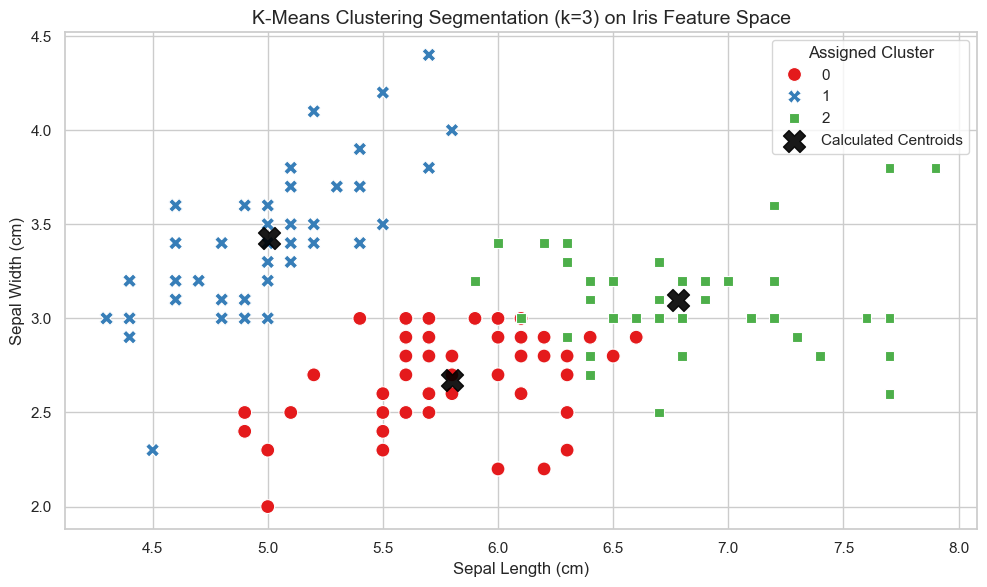

In [3]:
from sklearn.cluster import KMeans

# 1. Initialize and fit the K-Means model
# n_clusters=3 is chosen because the Iris problem space natively splits into 3 morphological groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_kmeans = X.copy()
df_kmeans['Cluster'] = kmeans.fit_predict(X_scaled)

print("--- K-Means Cluster Demographics ---")
print(df_kmeans['Cluster'].value_counts())

# 2. Visualization: Scatter plot utilizing Sepal dimensions
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_kmeans, 
    x='sepal length (cm)', 
    y='sepal width (cm)', 
    hue='Cluster', 
    palette='Set1', 
    style='Cluster',
    s=100
)

# Extract and scale back centroids for spatial overlay accuracy
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0], centroids[:, 1], 
    c='black', s=250, alpha=0.9, marker='X', 
    label='Calculated Centroids'
)

plt.title('K-Means Clustering Segmentation (k=3) on Iris Feature Space')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Assigned Cluster')
plt.tight_layout()
plt.show()

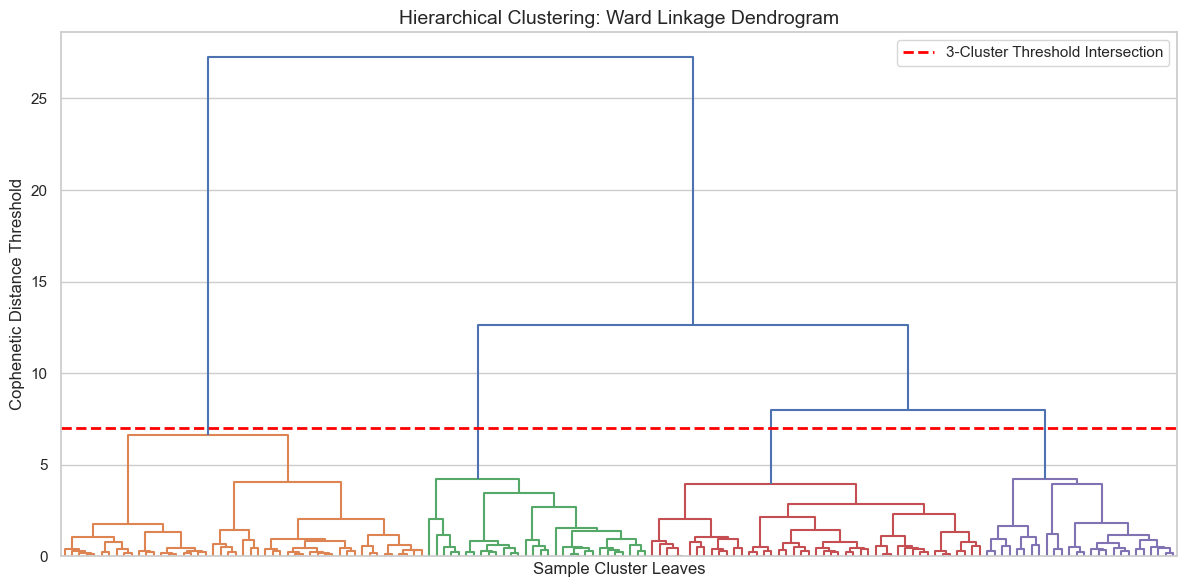

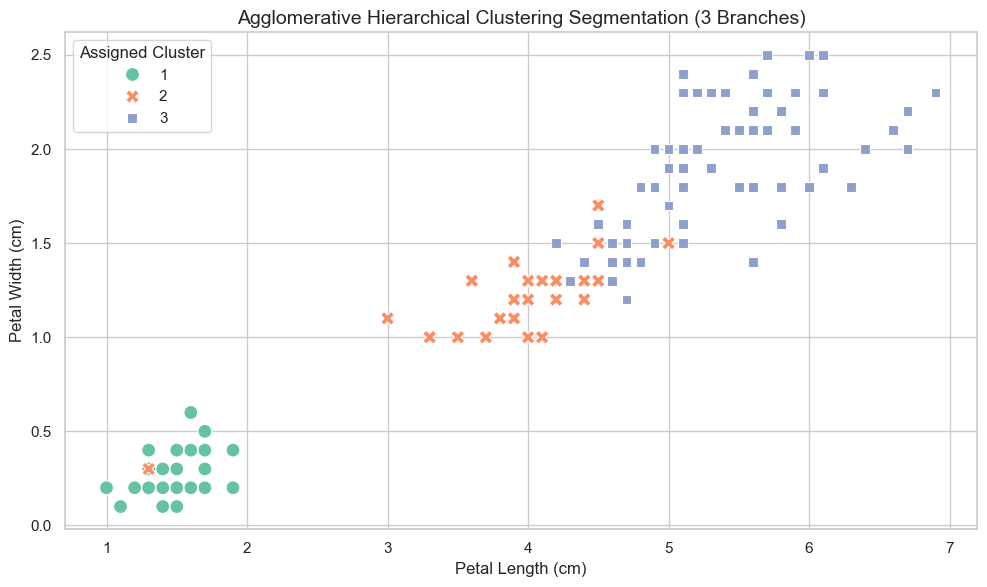

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1. Perform Hierarchical Linkage using Ward's minimum variance optimization method
Z = linkage(X_scaled, method='ward')

# 2. Visualization 1: Dendrogram representation of the cluster hierarchy
plt.figure(figsize=(12, 6))
dendrogram(
    Z, 
    no_labels=True, 
    color_threshold=7.0  # Visually colors the distinct branches below the distance line
)
plt.axhline(y=7.0, color='red', linestyle='--', linewidth=2, label='3-Cluster Threshold Intersection')
plt.title('Hierarchical Clustering: Ward Linkage Dendrogram')
plt.xlabel('Sample Cluster Leaves')
plt.ylabel('Cophenetic Distance Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Form exactly 3 flat clusters from the linkage matrix
hierarchical_labels = fcluster(Z, t=3, criterion='maxclust')
df_hierarchical = X.copy()
df_hierarchical['Cluster'] = hierarchical_labels

# 4. Visualization 2: Scatter plot utilizing Petal dimensions
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_hierarchical, 
    x='petal length (cm)', 
    y='petal width (cm)', 
    hue='Cluster', 
    palette='Set2', 
    style='Cluster',
    s=100
)
plt.title('Agglomerative Hierarchical Clustering Segmentation (3 Branches)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Assigned Cluster')
plt.tight_layout()
plt.show()